In [10]:
import json
from http.client import RemoteDisconnected
from json import JSONDecodeError
from pathlib import Path
from typing import Optional, TypeAlias
from urllib.error import HTTPError
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
from monty.json import MontyEncoder
from mp_api.client import MPRester
from numpy.typing import ArrayLike
from tqdm import tqdm
from dotenv import get_key

In [11]:
SERVER = "https://aflow.org"
API = "/API/aflux/?"

MP_API_KEY = get_key(Path().resolve().parent / ".env", "MATERIALS_PROJECT_API_KEY")

ROOT = ".."

In [12]:
AfluxResponse: TypeAlias = list[dict[str, str]] | list
OptionalRange: TypeAlias = Optional[tuple[int, int]]
PathLike: TypeAlias = str | Path

In [13]:
def aflux_request(
    matchbook: str,
    paging: Optional[int] = None,
    paging_range: OptionalRange = None,
    no_directives: bool = False,
    retries: int = 0,
) -> AfluxResponse:
    """Download a AFLUX response and return it as list of dictionaries"""
    if paging is not None and paging_range is not None:
        raise ValueError("Cannot specify both paging and paging_range")

    request_url = SERVER + API + matchbook

    if not no_directives:
        if paging is not None:
            request_url += f",$paging({paging}),format(json)"
        elif paging_range is not None:
            request_url += f",$paging({paging_range[0]},{paging_range[1]}),format(json)"
        else:
            request_url += ",$paging(0),format(json)"

    try:
        server_response = urlopen(request_url)
    except RemoteDisconnected:
        if retries > 0:
            print("RemoteDisconnected error, retrying...")
            return aflux_request(matchbook, paging, paging_range, no_directives, retries - 1)
        else:
            print("RemoteDisconnected error, no more retries left")
    else:
        response_content = server_response.read().decode("utf-8")

    # Basic error handling
    if server_response.getcode() == 200:
        try:
            print("AFLUX request successful!")
            return json.loads(response_content)
        except JSONDecodeError:
            pass

    print("AFLUX request failed!")
    print(f"  URL: {request_url}")
    print(f"  Response: {response_content}")
    return None

In [14]:
def aflux_help(keyword: Optional[str] = None) -> None:
    """Print the build in help of AFLUX"""
    if keyword is None:
        # General help (https://aflow.org/API/aflux/?)
        help_data = aflux_request("", no_directives=True)
        print("\n".join(help_data))
    else:
        # Help regarding a specific keyword (https://aflow.org/API/aflux/?help(keyword))
        help_data = aflux_request(f"help({keyword})")
        for key, entry in help_data.items():
            print(key)
            print(f"  description: {entry['description']}")
            print(f"  units: {entry['units']}")
            print(f"  status: {entry['status']}")
            comment = "\n    ".join(entry["__comment__"]).strip()
            if comment:
                print(f"  comment:\n    {comment}")

In [15]:
def aflux_get_contcar(entry: dict[str, str]) -> str | None:
    """Get a CONTCAR from AFLUX"""
    request_url = "http://" + entry["aurl"].replace(":", "/") + "/" + "CONTCAR.relax"
    server_response = urlopen(request_url)
    response_content = server_response.read().decode("utf-8")
    if server_response.getcode() == 200:
        # Fix POSTCAR if in VASP4 format
        poscar_lines = response_content.split("\n")
        # Add species names if missing
        if poscar_lines[5].strip()[0].isnumeric():
            poscar_lines.insert(5, " ".join(entry["species"]))
        poscar = "\n".join(poscar_lines)
        return poscar
    print("AFLUX request failed!")
    print(f"  URL: {request_url}")
    print(f"  Response: {response_content}")
    return None

In [16]:
def aflux_get_property(entry: dict[str, str], property: str) -> float | None:
    """Get a property from AFLUX"""
    aurl = entry["aurl"].replace(":", "/")
    request_url = f"http://{aurl}/?{property}"
    server_response = urlopen(request_url)
    response_content = server_response.read().decode("utf-8")
    if server_response.getcode() == 200:
        # Fix POSTCAR if in VASP4 format
        poscar_lines = response_content.split("\n")
        # Add species names if missing
        if poscar_lines[5].strip()[0].isnumeric():
            poscar_lines.insert(5, " ".join(entry["species"]))
        poscar = "\n".join(poscar_lines)
        return poscar
    print("AFLUX request failed!")
    print(f"  URL: {request_url}")
    print(f"  Response: {response_content}")
    return None

In [17]:
def clean_nones(value):
    """
    Recursively remove all None values from dictionaries and lists, and returns
    the result as a new dictionary or list.
    """
    if isinstance(value, list):
        return [clean_nones(x) for x in value if x is not None]
    elif isinstance(value, dict):
        return {key: clean_nones(val) for key, val in value.items() if val is not None}
    else:
        return value

In [18]:
def clean_mp_entries(entries):
    """
    Clean a list of entries from the MP database, removing all None values.
    """
    for entry in entries:
        if entry["deprecated"] or entry["warnings"]:
            del entry
            continue

        entry["structure"] = entry["structure"].to("POSCAR")
        entry["spacegroup"] = entry["symmetry"]["number"]

        entry["symmetry"] = None
        entry["deprecated"] = None
        entry["warnings"] = None

    return clean_nones(entries)

In [19]:
def load_sg_from_dataset(path: PathLike) -> list[int]:
    if not isinstance(path, Path):
        path = Path(path)

    dataset = []
    for i in range(1, 231):
        file = path / f"data_{i}.json"
        if not file.exists():
            continue

        data = json.loads(file.read_text())
        if data:
            if "spacegroup_relax" in data[0].keys():
                for entry in data:
                    entry["spacegroup"] = entry["spacegroup_relax"]
                    del entry["spacegroup_relax"]

            dataset += [int(entry["spacegroup"]) for entry in data]

    return dataset

In [44]:
def plot_spacegroup_distribution(dataset: ArrayLike, ax=None, title=None) -> None:
    sg_unique, sg_count = np.unique(dataset, return_counts=True)
    sg_percentage = sg_count / np.sum(sg_count)

    for i in range(1, 231):
        if i not in sg_unique:
            sg_unique = np.insert(sg_unique, i, i)
            sg_percentage = np.insert(sg_percentage, i, 0)

    print(f"Spacegroup without data: {np.where(sg_percentage == 0)[0]}")

    if ax is None:
        ax = plt.gca()

    ax.bar(sg_unique, sg_percentage, log=True, width=1)

    ax.set_xlim(1, 230)
    ax.set_xlabel("Space group")
    ax.set_ylabel("Percentage of entries")
    if title:
        ax.set_title(title)

In [ ]:
%%script false --no-raise-error
for sg in tqdm(range(1, 231)):
    file = Path(f"{ROOT}/dataset/aflow/data_{sg}.json")

    if file.is_file():
        continue

    i = 1
    data = None
    total_data = []
    while data != []:
        try:
            data = aflux_request(f"spacegroup_relax({sg})", paging_range=(i, 200_000))
        except HTTPError as e:
            print(f"Unable to fetch data for spacegroup {sg}: {e}\n")
        else:
            i += 1
            total_data += data

    if total_data:
        file.write_text(json.dumps(total_data, indent=4))

In [ ]:
%%script false --no-raise-error
for i in tqdm(range(1, 231)):
    file = Path(f"{ROOT}/dataset/mp/data_{i}.json")
    if file.is_file():
        continue

    with MPRester(MP_API_KEY, mute_progress_bars=True, use_document_model=False) as mpr:
        docs = mpr.materials.summary.search(
            spacegroup_number=i,
            fields=["material_id", "symmetry", "structure", "deprecated", "warnings"],
        )

    docs = clean_mp_entries(docs)

    file.write_text(json.dumps(docs, indent=4, allow_nan=False, cls=MontyEncoder))

In [21]:
import pandas as pd

df = pd.read_csv(f"{ROOT}/data/gnome_data/stable_materials_summary.csv")

In [23]:
pd.set_option('display.max_columns', None)
df.head()

,Unnamed: 0,Composition,MaterialId,Reduced Formula,Elements,NSites,Volume,Density,Point Group,Space Group,Space Group Number,Crystal System,Corrected Energy,Formation Energy Per Atom,Decomposition Energy Per Atom,Dimensionality Cheon,Bandgap,Is Train,Decomposition Energy Per Atom All,Decomposition Energy Per Atom Relative,Decomposition Energy Per Atom MP,Decomposition Energy Per Atom MP OQMD
0,0,Cs1S6Zr3,000006a8c4,Cs(ZrS2)3,"['S', 'Zr', 'Cs']",10,302.9202,3.2834,2/m,C2/m,12,monoclinic,-70.4155,-1.9058,-0.1625,intercalated ion,0.0023,True,0.0,NaN,-0.1625,-0.0733
1,1,Nd7Os1Pr3Si5,00011f62be,Pr3Nd7Si5Os,"['Si', 'Pr', 'Nd', 'Os']",16,430.2851,6.8040,1,P1,1,triclinic,-94.0804,-0.5004,-0.0137,3D,0.0022,True,0.0,NaN,-0.0137,-0.0106
2,2,Ce2La3Pt16Tm15,00012feb99,La3Ce2Tm15Pt16,"['La', 'Ce', 'Tm', 'Pt']",36,828.6647,12.7292,1,P1,1,triclinic,-237.6016,-1.2960,-0.1195,3D,NaN,True,0.0,NaN,-0.1195,-0.1185
3,3,Mn1Ni1Os2Sb12Yb1,00014cac13,YbMnNi(Sb6Os)2,"['Mn', 'Ni', 'Sb', 'Yb', 'Os']",17,407.2614,8.6776,-1,P-1,2,triclinic,-93.6931,-0.3064,-0.0837,3D,0.0011,True,-0.0,NaN,-0.0837,-0.0772
4,4,Er8Ge4Si12Zr12,0001759321,Er2Zr3Si3Ge,"['Si', 'Ge', 'Zr', 'Er']",36,727.5283,6.9851,1,P1,1,triclinic,-254.0953,-0.8718,-0.0186,3D,inf,True,-0.0,NaN,-0.0186,-0.0176


In [28]:
aflow_data = load_sg_from_dataset("../data/aflow")
print(f"Number of entries (aflow): {len(aflow_data)}")

mp_data = load_sg_from_dataset("../data/mp")
print(f"Number of entries (mp): {len(mp_data)}")

gnome_data = df["Space Group Number"].values.tolist()
print(f"Number of entries (gnome): {len(gnome_data)}")

total_data = aflow_data + mp_data + gnome_data
print(f"Number of entries (total): {len(total_data)}")

Number of entries (aflow): 3529787
Number of entries (mp): 153235
Number of entries (gnome): 384871
Number of entries (total): 4067893


Spacegroup without data: [ 49  89  93  94 101 168 171 172 207 209 228]
Spacegroup without data: [168 207]
Spacegroup without data: [ 48  78  93  96 106 153 158 168 169 170 171 172 178 179 184 195 207 208
 210 211 219 222 228]
Spacegroup without data: [168 207]


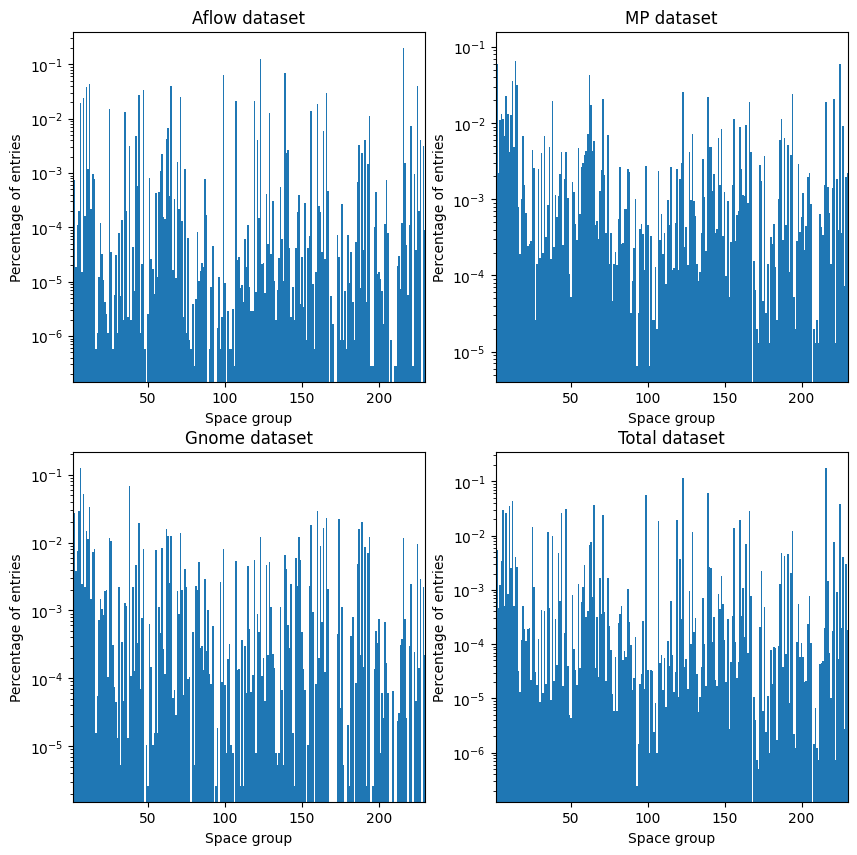

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for i, dataset in enumerate([aflow_data, mp_data, gnome_data, total_data]):
    plot_spacegroup_distribution(dataset, axes.flatten()[i], title=["Aflow", "MP", "Gnome", "Total"][i] + " dataset")

plt.show()